# Notebook 1 — Data Exploration

Loads the Brain Tumor MRI dataset (4 classes), counts images, checks sizes, displays samples.

In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent
DATASET_PATH = PROJECT_DIR / "data" / "brain_tumor_mri_dataset"
FIGURES_DIR  = PROJECT_DIR / "outputs" / "figures_v2"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ORIGINAL_CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

BINARY_LABEL_MAP = {
    "glioma": 1,
    "meningioma": 1,
    "pituitary": 1,
    "notumor": 0
}

BINARY_CLASS_MAP = {
    1: "tumor",
    0: "no_tumor"
}

BINARY_CLASSES = ["no_tumor", "tumor"]

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATASET_PATH)
print("Exists:", DATASET_PATH.exists())

Project directory: C:\Users\elifn\DSAI 583\PROJECT
Dataset path: C:\Users\elifn\DSAI 583\PROJECT\data\brain_tumor_mri_dataset
Exists: True


In [2]:
valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}

records = []

for split in ["Training", "Testing"]:
    for original_class in ORIGINAL_CLASSES:
        folder = DATASET_PATH / split / original_class
        
        if not folder.exists():
            print(f"WARNING: {folder} not found")
            continue
        
        for p in folder.iterdir():
            if p.suffix.lower() in valid_ext:
                binary_label = BINARY_LABEL_MAP[original_class]
                binary_class = BINARY_CLASS_MAP[binary_label]
                
                records.append({
                    "path": p,
                    "original_class": original_class,
                    "label": binary_label,
                    "class_name": binary_class,
                    "split": split.lower()
                })

df = pd.DataFrame(records)

print(f"Total images: {len(df)}")

print("\nOriginal class distribution:")
print(df.groupby(["split", "original_class"]).size().unstack(fill_value=0))

print("\nBinary class distribution:")
print(df.groupby(["split", "class_name"]).size().unstack(fill_value=0))

Total images: 7200

Original class distribution:
original_class  glioma  meningioma  notumor  pituitary
split                                                 
testing            400         400      400        400
training          1400        1400     1400       1400

Binary class distribution:
class_name  no_tumor  tumor
split                      
testing          400   1200
training        1400   4200


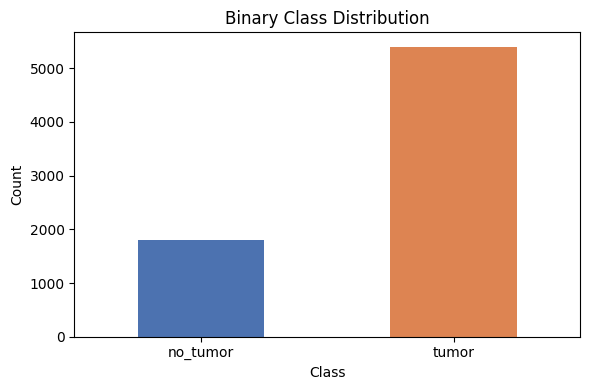

In [3]:
plt.figure(figsize=(6, 4))

df["class_name"].value_counts().loc[BINARY_CLASSES].plot(
    kind="bar",
    color=["#4C72B0", "#DD8452"]
)

plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_binary_class_distribution.png", dpi=150)
plt.show()

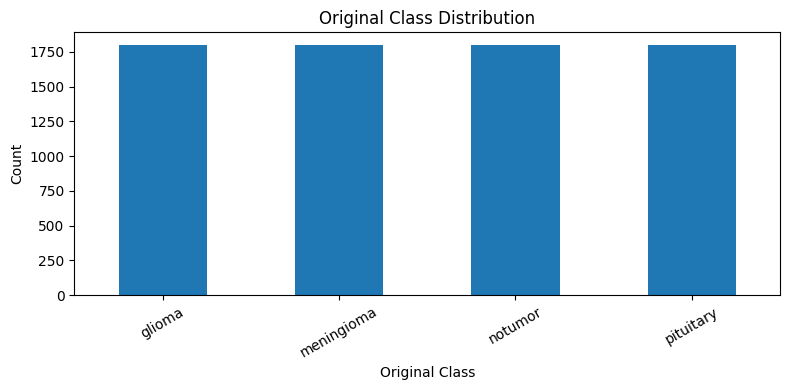

In [4]:
plt.figure(figsize=(8, 4))

df["original_class"].value_counts().loc[ORIGINAL_CLASSES].plot(kind="bar")

plt.title("Original Class Distribution")
plt.xlabel("Original Class")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_original_class_distribution.png", dpi=150)
plt.show()

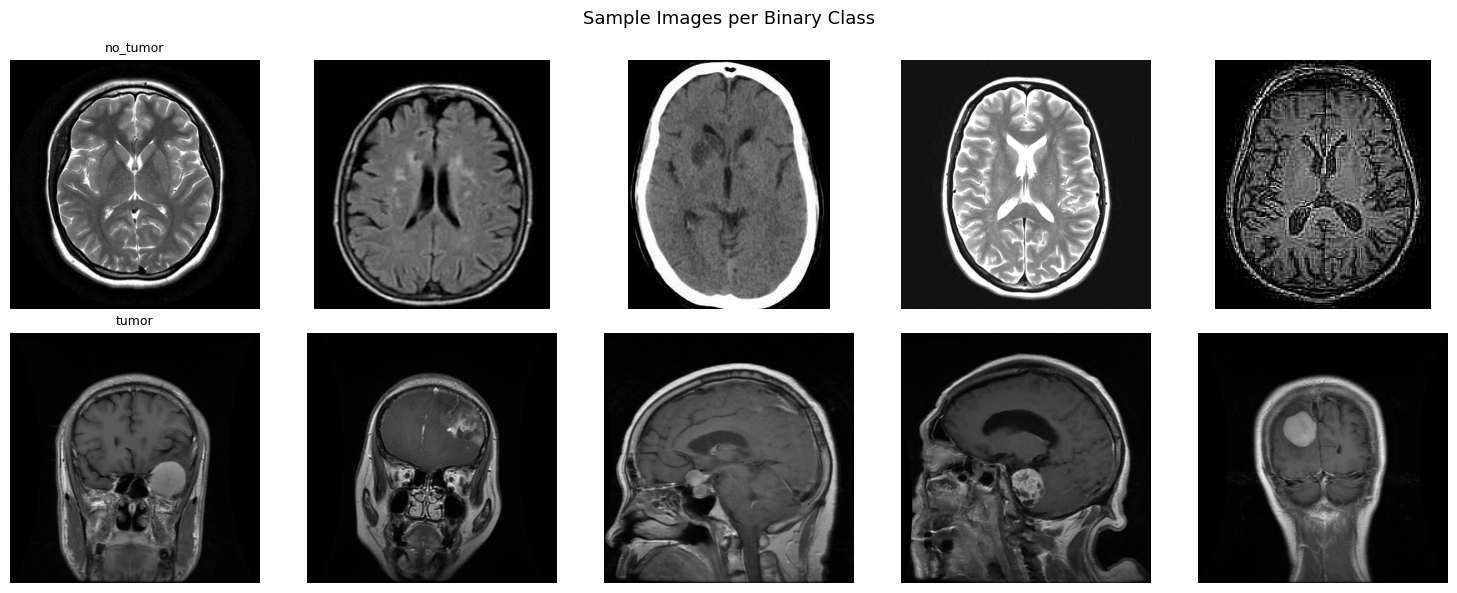

In [5]:
# Sample images per binary class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, class_name in enumerate(BINARY_CLASSES):
    samples = df[df["class_name"] == class_name].sample(5, random_state=42)
    
    for col, (_, r) in enumerate(samples.iterrows()):
        img = cv2.imread(str(r["path"]), cv2.IMREAD_GRAYSCALE)
        
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(class_name if col == 0 else "", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Sample Images per Binary Class", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_binary_sample_images.png", dpi=150)
plt.show()

In [7]:
# Image size distribution
shapes = []
for _, r in df.iterrows():
    img = cv2.imread(str(r["path"]), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        shapes.append(img.shape)

print(f"Unique shapes: {len(set(shapes))}")
h = [s[0] for s in shapes]; w = [s[1] for s in shapes]
print(f"Height range: {min(h)}–{max(h)}, Width range: {min(w)}–{max(w)}")

Unique shapes: 447
Height range: 167–1446, Width range: 150–1375
